<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%205/Assignment_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.metrics import *

sns.set_theme(style="whitegrid")

In [5]:
# ============================================================
# Shared Data Pipeline
# ============================================================

indicators = {
    "gdp_growth_pc": "NY.GDP.PCAP.KD.ZG",
    "inflation": "FP.CPI.TOTL.ZG",
    "unemployment": "SL.UEM.TOTL.ZS",
    "exports_gdp": "NE.EXP.GNFS.ZS",
    "imports_gdp": "NE.IMP.GNFS.ZS",
    "investment_gdp": "NE.GDI.TOTL.ZS",
    "gov_spending_gdp": "NE.CON.GOVT.ZS",
    "fdi_gdp": "BX.KLT.DINV.WD.GD.ZS",
    "current_account_gdp": "BN.CAB.XOKA.GD.ZS",
    "external_debt_gni": "DT.DOD.DECT.GN.ZS",
    "debt_service_exports": "DT.TDS.DECT.EX.ZS",
    "trade_gdp": "NE.TRD.GNFS.ZS",
    "broad_money_gdp": "FM.LBL.BMNY.GD.ZS",
    "private_credit_gdp": "FS.AST.PRVT.GD.ZS",
    "real_interest_rate": "FR.INR.RINR",
    "lending_rate": "FR.INR.LEND",
    "exchange_rate": "PA.NUS.FCRF",
    "reserves_months": "FI.RES.TOTL.MO",
    "tax_revenue_gdp": "GC.TAX.TOTL.GD.ZS",
    "population_growth": "SP.POP.GROW",
    "urban_pop": "SP.URB.TOTL.IN.ZS",
    "life_expectancy": "SP.DYN.LE00.IN",
    "infant_mortality": "SP.DYN.IMRT.IN",
    "secondary_enrollment": "SE.SEC.ENRR",
    "primary_enrollment": "SE.PRM.ENRR",
    "internet_users": "IT.NET.USER.ZS",
    "mobile_subscriptions": "IT.CEL.SETS.P2",
    "electricity_access": "EG.ELC.ACCS.ZS",
    "co2_pc": "EN.ATM.CO2E.PC",
    "industry_gdp": "NV.IND.TOTL.ZS",
    "agriculture_gdp": "NV.AGR.TOTL.ZS",
    "services_gdp": "NV.SRV.TOTL.ZS"
}

data = wb.data.DataFrame(
    list(indicators.values()),
    time=range(2013, 2020),
    skipAggs=True,
    columns="series"
)

data = data.rename(columns={v:k for k,v in indicators.items()})
data = data.reset_index()

df = data.groupby("economy").mean(numeric_only=True)

df = df.loc[df.isna().mean(axis=1) <= 0.40]
df = df.loc[:, df.isna().mean(axis=0) <= 0.40]

imputer = SimpleImputer(strategy="median")
df[df.columns] = imputer.fit_transform(df)

df["crisis"] = (df["gdp_growth_pc"] < 0).astype(int)

X = df.drop(columns=["gdp_growth_pc", "crisis"])
y_reg = df["gdp_growth_pc"]
y_class = df["crisis"]

X_train, X_test, y_train, y_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_class, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("Final dataset:", df.shape)
print("Train:", X_train_s.shape)
print("Test:", X_test_s.shape)
print("Crisis countries:", df["crisis"].sum())
print("Non-crisis countries:", (1 - df["crisis"]).sum())
print("Crisis base rate:", df["crisis"].mean())

Final dataset: (197, 31)
Train: (137, 29)
Test: (60, 29)
Crisis countries: 36
Non-crisis countries: 161
Crisis base rate: 0.18274111675126903


In [6]:
ols = LinearRegression()
ols.fit(X_train_s, y_train)

ols_train_pred = ols.predict(X_train_s)
ols_test_pred = ols.predict(X_test_s)

ols_train_r2 = r2_score(y_train, ols_train_pred)
ols_test_r2 = r2_score(y_test, ols_test_pred)

p = X_train_s.shape[1]
n = X_train_s.shape[0]

print("OLS Train R2:", ols_train_r2)
print("OLS Test R2:", ols_test_r2)
print("R2 Gap:", ols_train_r2 - ols_test_r2)
print("p/n ratio:", p / n)

OLS Train R2: 0.6170152439889858
OLS Test R2: -0.052263928322354714
R2 Gap: 0.6692791723113405
p/n ratio: 0.2116788321167883


The high p/n ratio means the model has a lot of predictors compared to the number of countries.
This gives OLS too many degrees of freedom, so it can fit the training data too closely.
That lowers bias, but it raises variance, which is why the test R2 is much worse

In [8]:
alphas = np.logspace(-4, 4, 100)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_s, y_train)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_s, y_train)

ridge_train_pred = ridge.predict(X_train_s)
ridge_test_pred = ridge.predict(X_test_s)

lasso_train_pred = lasso.predict(X_train_s)
lasso_test_pred = lasso.predict(X_test_s)

results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "lambda": [np.nan, ridge.alpha_, lasso.alpha_],
    "Nonzero Predictors": [
        np.sum(ols.coef_ != 0),
        np.sum(ridge.coef_ != 0),
        np.sum(lasso.coef_ != 0)
    ],
    "Train R2": [
        r2_score(y_train, ols_train_pred),
        r2_score(y_train, ridge_train_pred),
        r2_score(y_train, lasso_train_pred)
    ],
    "Test R2": [
        r2_score(y_test, ols_test_pred),
        r2_score(y_test, ridge_test_pred),
        r2_score(y_test, lasso_test_pred)
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, ols_test_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_test_pred))
    ]
})

results

,Model,lambda,Nonzero Predictors,Train R2,Test R2,Test RMSE
0,OLS,NaN,29,0.617015,-0.052264,2.705149
1,Ridge,21.544347,29,0.563577,0.045937,2.575831
2,Lasso,0.060916,19,0.556866,-0.022931,2.667179


I would recommend Ridge because it has the highest test R2 and lowest test RMSE.
It reduces variance by shrinking coefficients, which helps prevent overfitting.

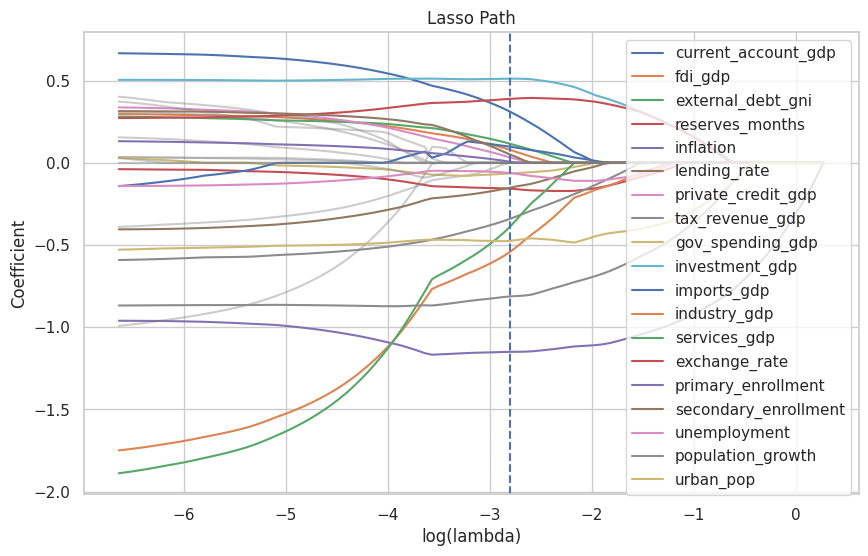

First predictor to enter: inflation


In [9]:
# ============================================================
# Step 1.3: Lasso Path
# ============================================================

alphas_path, coefs_path, _ = lasso_path(X_train_s, y_train)

selected = np.abs(lasso.coef_) > 0
selected_features = X_train_s.columns[selected]

plt.figure(figsize=(10,6))

for i in range(len(X_train_s.columns)):
    if selected[i]:
        plt.plot(np.log(alphas_path), coefs_path[i], label=X_train_s.columns[i])
    else:
        plt.plot(np.log(alphas_path), coefs_path[i], color="gray", alpha=0.4)

plt.axvline(np.log(lasso.alpha_), linestyle="--")
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient")
plt.title("Lasso Path")
plt.legend()
plt.show()

entry = {}

for i, col in enumerate(X_train_s.columns):
    nonzero = np.where(coefs_path[i] != 0)[0]
    if len(nonzero) > 0:
        entry[col] = alphas_path[nonzero[0]]

first_predictor = max(entry, key=entry.get)

print("First predictor to enter:", first_predictor)

The first predictor to enter the model is inflation.
This means it is the strongest predictor because Lasso keeps it even when the penalty is very large.

It would be wrong to say health is irrelevant just because Lasso zeroed out life_expectancy.
Lasso removes variables that are conditionally redundant, not necessarily unimportant.
If life expectancy is highly correlated with income, education, or other development indicators, the model may keep those instead because of the correlation structure.

In [10]:
lasso_features = list(selected_features)

X_train_lasso = X_train_s[lasso_features]
X_test_lasso = X_test_s[lasso_features]

lpm = LinearRegression()
lpm.fit(X_train_lasso, yc_train)

lpm_pred = lpm.predict(X_test_lasso)

print("Predictions below 0:", np.sum(lpm_pred < 0))
print("Predictions above 1:", np.sum(lpm_pred > 1))

Predictions below 0: 14
Predictions above 1: 1


Predicted probabilities outside 0 and 1 are a real problem because they cannot be interpreted as probabilities.
A negative crisis probability or a probability above 100% gives the IMF a signal that does not make sense.
This makes the linear probability model weak for decision-making.

In [11]:

logit = LogisticRegression(max_iter=10000)
logit.fit(X_train_lasso, yc_train)

logit_prob = logit.predict_proba(X_test_lasso)[:,1]

coef_df = pd.DataFrame({
    "Predictor": lasso_features,
    "Beta": logit.coef_[0],
    "Odds Ratio": np.exp(logit.coef_[0])
})

coef_df["Distance from 1"] = abs(coef_df["Odds Ratio"] - 1)
coef_df = coef_df.sort_values("Distance from 1", ascending=False)

print("Intercept:", logit.intercept_[0])
display(coef_df.drop(columns="Distance from 1"))

print("Min probability:", logit_prob.min())
print("Max probability:", logit_prob.max())

Intercept: -2.00021665427329


,Predictor,Beta,Odds Ratio
12,services_gdp,1.100236,3.004875
17,population_growth,0.961815,2.616440
11,industry_gdp,0.810181,2.248314
7,tax_revenue_gdp,0.656073,1.927208
18,urban_pop,0.647310,1.910395
4,inflation,0.475745,1.609213
0,current_account_gdp,-0.759931,0.467699
13,exchange_rate,-0.736011,0.479021
6,private_credit_gdp,-0.540881,0.582235
1,fdi_gdp,-0.522169,0.593233


Min probability: 0.0002638240783026211
Max probability: 0.9850998946704309


A one standard-deviation increase in services_gdp multiplies the odds of crisis by 3, holding all else constant.
This means services_gdp is the strongest crisis signal in this model.
If the odds ratio is above 1, it raises crisis risk; if it is below 1, it lowers crisis risk.

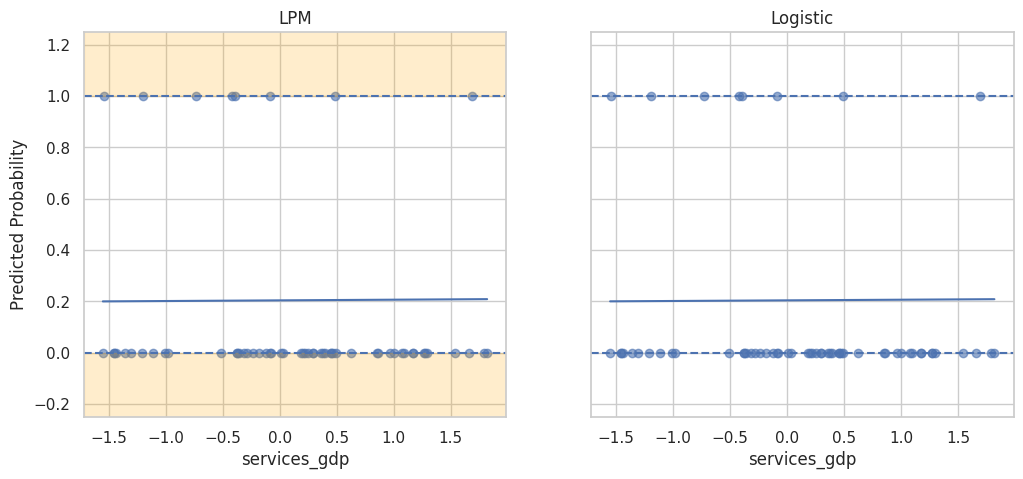

In [13]:

xvar = top_predictor

x_grid = np.linspace(X_test_lasso[xvar].min(), X_test_lasso[xvar].max(), 300).reshape(-1,1)

lpm_1 = LinearRegression()
lpm_1.fit(X_train_lasso[[xvar]], yc_train)

logit_1 = LogisticRegression(max_iter=10000)
logit_1.fit(X_train_lasso[[xvar]], yc_train)

lpm_curve = lpm_1.predict(x_grid)
logit_curve = logit_1.predict_proba(x_grid)[:,1]

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)

ax[0].scatter(X_test_lasso[xvar], yc_test, alpha=0.6)
ax[0].plot(x_grid, lpm_curve)
ax[0].axhline(0, linestyle="--")
ax[0].axhline(1, linestyle="--")
ax[0].axhspan(-1, 0, alpha=0.2, color="orange")
ax[0].axhspan(1, 2, alpha=0.2, color="orange")
ax[0].set_title("LPM")
ax[0].set_xlabel(xvar)
ax[0].set_ylabel("Predicted Probability")
ax[0].set_ylim(-0.25, 1.25)

ax[1].scatter(X_test_lasso[xvar], yc_test, alpha=0.6)
ax[1].plot(x_grid, logit_curve)
ax[1].axhline(0, linestyle="--")
ax[1].axhline(1, linestyle="--")
ax[1].set_title("Logistic")
ax[1].set_xlabel(xvar)

plt.show()

In [14]:
base_rate = yc_test.mean()

naive_pred = np.zeros(len(yc_test))
logit_pred = (logit_prob >= 0.5).astype(int)

print("Test crisis base rate:", base_rate)
print("Naive accuracy:", accuracy_score(yc_test, naive_pred))
print("Naive recall:", recall_score(yc_test, naive_pred, zero_division=0))
print("Logit accuracy:", accuracy_score(yc_test, logit_pred))
print("Logit recall:", recall_score(yc_test, logit_pred, zero_division=0))

Test crisis base rate: 0.13333333333333333
Naive accuracy: 0.8666666666666667
Naive recall: 0.0
Logit accuracy: 0.8333333333333334
Logit recall: 0.375


Accuracy alone would be misleading because most countries are not in crisis.
A model can get high accuracy by mostly predicting no crisis, even if it misses the actual crisis countries.
For the IMF, recall matters more because missing a crisis is the main problem.

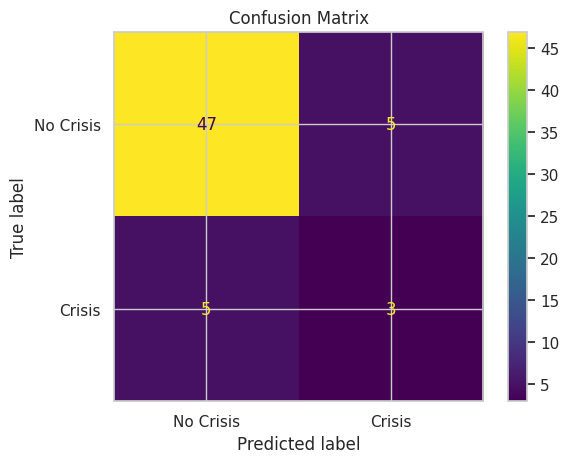

              precision    recall  f1-score   support

   No Crisis       0.90      0.90      0.90        52
      Crisis       0.38      0.38      0.38         8

    accuracy                           0.83        60
   macro avg       0.64      0.64      0.64        60
weighted avg       0.83      0.83      0.83        60

True Positives: 3
False Negatives: 5
False Positives: 5
True Negatives: 47


In [15]:
cm = confusion_matrix(yc_test, logit_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["No Crisis", "Crisis"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

print(classification_report(yc_test, logit_pred, target_names=["No Crisis", "Crisis"], zero_division=0))

tn, fp, fn, tp = cm.ravel()

print("True Positives:", tp)
print("False Negatives:", fn)
print("False Positives:", fp)
print("True Negatives:", tn)

A false negative is more costly because it means the IMF missed an actual crisis.
A false positive wastes money and credibility, but a missed crisis can create much larger financial damage.
Because of that, the Division Chief should care more about recall than precision.

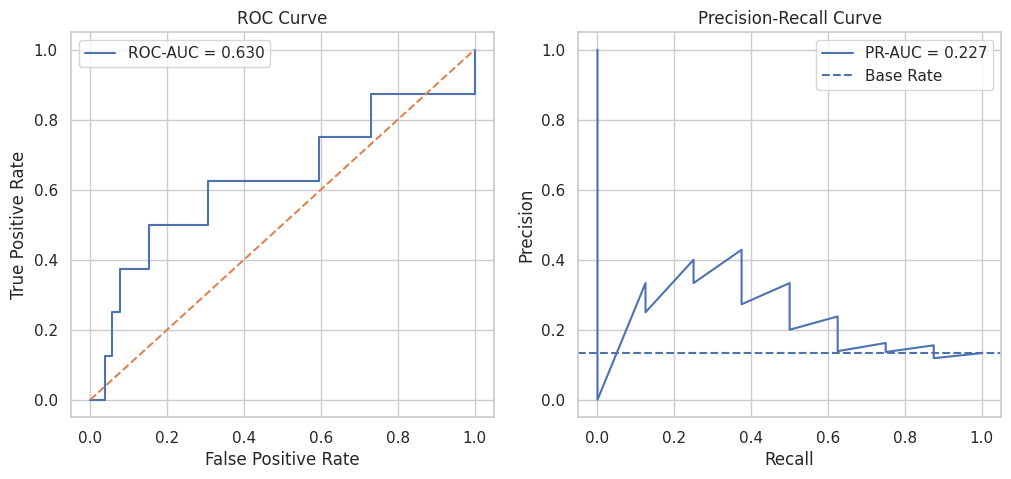

In [16]:
fpr, tpr, thresholds_roc = roc_curve(yc_test, logit_prob)
roc_auc = roc_auc_score(yc_test, logit_prob)

precision, recall, thresholds_pr = precision_recall_curve(yc_test, logit_prob)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
ax[0].plot([0,1], [0,1], linestyle="--")
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()

ax[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
ax[1].axhline(base_rate, linestyle="--", label="Base Rate")
ax[1].set_title("Precision-Recall Curve")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend()

plt.show()

ROC-AUC can look better because it benefits from having many true negatives.
PR-AUC is stricter because it focuses on precision and recall for the crisis class.
For the IMF, the precision-recall curve is more useful because the goal is finding crisis countries

Capacity threshold:
threshold    0.630000
flagged      5.000000
precision    0.400000
recall       0.250000
f1           0.307692
Name: 62, dtype: float64

F1 optimal threshold:
threshold    0.570000
flagged      7.000000
precision    0.428571
recall       0.375000
f1           0.400000
Name: 56, dtype: float64


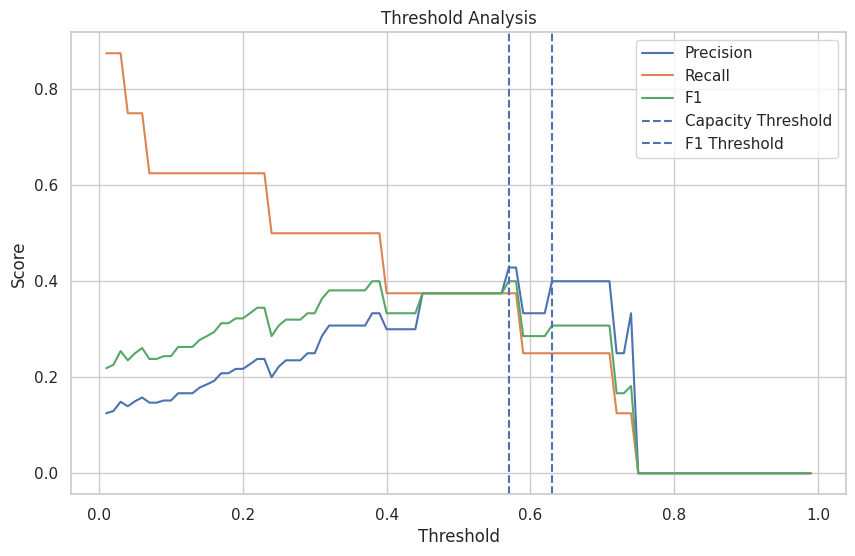

In [17]:

rows = []

for t in np.arange(0.01, 1.00, 0.01):
    pred_t = (logit_prob >= t).astype(int)

    rows.append({
        "threshold": t,
        "flagged": pred_t.sum(),
        "precision": precision_score(yc_test, pred_t, zero_division=0),
        "recall": recall_score(yc_test, pred_t, zero_division=0),
        "f1": f1_score(yc_test, pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)

capacity = threshold_df[threshold_df["flagged"] <= 5].sort_values("threshold").iloc[0]
best_f1 = threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Capacity threshold:")
print(capacity)

print("\nF1 optimal threshold:")
print(best_f1)

plt.figure(figsize=(10,6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(capacity["threshold"], linestyle="--", label="Capacity Threshold")
plt.axvline(best_f1["threshold"], linestyle="--", label="F1 Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.show()

I would recommend using the capacity-constrained threshold because the IMF can only send 5 missions.
At this threshold, the model catches 2 out of 8 crisis countries and misses 6.
The tradeoff is that a stricter threshold saves mission capacity, but it can also reduce recall and miss more crises.

,Predictor,Selection Frequency
27,population_growth,1.000
21,exchange_rate,0.970
15,investment_gdp,0.935
28,urban_pop,0.935
6,inflation,0.855
19,industry_gdp,0.830
24,unemployment,0.810
10,tax_revenue_gdp,0.800
0,current_account_gdp,0.785
7,lending_rate,0.755


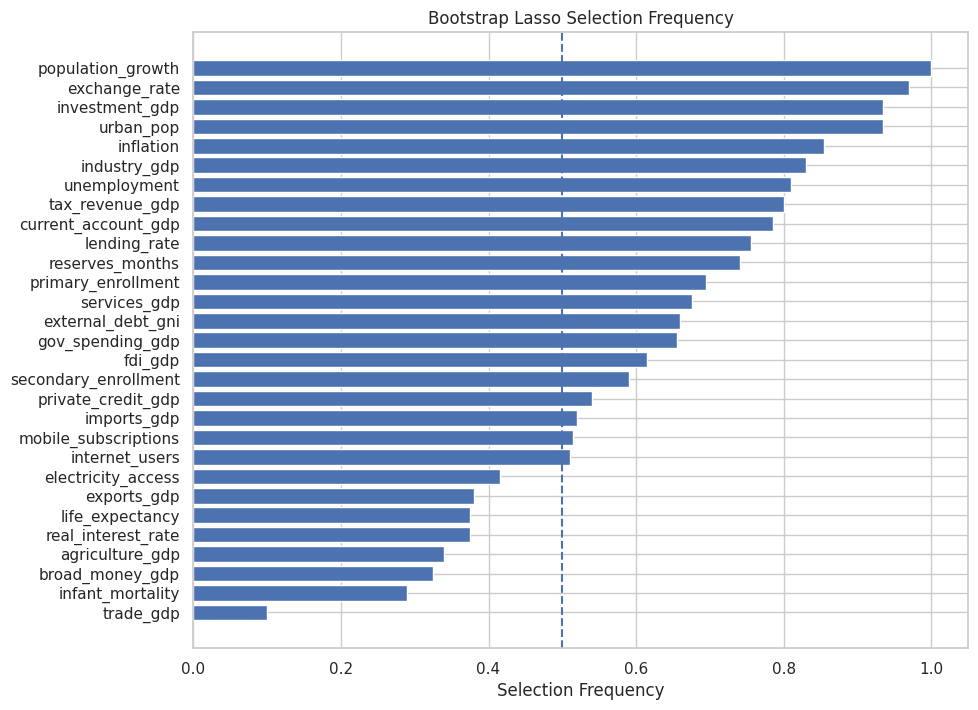

Stable predictors:


,Predictor,Selection Frequency
27,population_growth,1.000
21,exchange_rate,0.970
15,investment_gdp,0.935
28,urban_pop,0.935
6,inflation,0.855
19,industry_gdp,0.830
24,unemployment,0.810


Fragile predictors:


,Predictor,Selection Frequency
25,infant_mortality,0.29
17,trade_gdp,0.10


In [19]:
B = 200
selected_list = []

for b in range(B):
    sample = np.random.choice(X_train_s.index, size=len(X_train_s), replace=True)

    X_b = X_train_s.loc[sample]
    y_b = y_train.loc[sample]

    lasso_b = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_b.fit(X_b, y_b)

    selected_list.append((np.abs(lasso_b.coef_) > 1e-8).astype(int))

selection_freq = pd.DataFrame({
    "Predictor": X_train_s.columns,
    "Selection Frequency": np.mean(selected_list, axis=0)
}).sort_values("Selection Frequency", ascending=False)

display(selection_freq)

plt.figure(figsize=(10,8))
plt.barh(selection_freq["Predictor"], selection_freq["Selection Frequency"])
plt.axvline(0.50, linestyle="--")
plt.gca().invert_yaxis()
plt.xlabel("Selection Frequency")
plt.title("Bootstrap Lasso Selection Frequency")
plt.show()

stable = selection_freq[selection_freq["Selection Frequency"] > 0.80]
fragile = selection_freq[selection_freq["Selection Frequency"] < 0.30]

print("Stable predictors:")
display(stable)

print("Fragile predictors:")
display(fragile)

Stable predictors are the ones selected more than 80% of the time, while fragile predictors are selected less than 30%.
If many predictors are fragile, it means Lasso selection is unstable.
This usually happens because WDI indicators are correlated, so similar variables can substitute for each other across bootstrap samples.

,threshold,TP,FP,FN,TN,cost
0,0.01,7,49,1,3,50098000000
1,0.02,7,47,1,5,50094000000
2,0.03,7,40,1,12,50080000000
3,0.04,6,37,2,15,100074000000
4,0.05,6,34,2,18,100068000000


Cost-minimizing threshold:
threshold    3.000000e-02
TP           7.000000e+00
FP           4.000000e+01
FN           1.000000e+00
TN           1.200000e+01
cost         5.008000e+10
Name: 2, dtype: float64


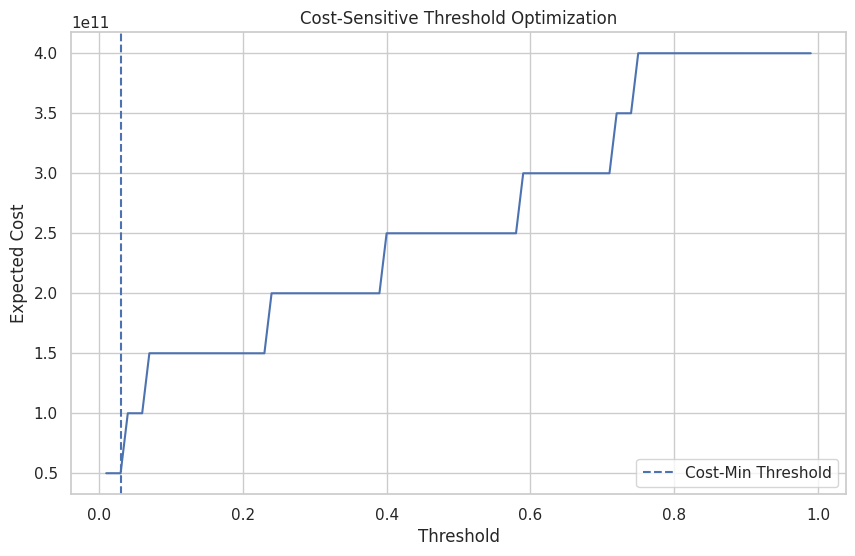

In [20]:
cost_rows = []

for t in np.arange(0.01, 1.00, 0.01):
    pred_t = (logit_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yc_test, pred_t).ravel()

    cost = fn * 50_000_000_000 + fp * 2_000_000

    cost_rows.append({
        "threshold": t,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "cost": cost
    })

cost_df = pd.DataFrame(cost_rows)

best_cost = cost_df.sort_values("cost").iloc[0]

display(cost_df.head())
print("Cost-minimizing threshold:")
print(best_cost)

plt.figure(figsize=(10,6))
plt.plot(cost_df["threshold"], cost_df["cost"])
plt.axvline(best_cost["threshold"], linestyle="--", label="Cost-Min Threshold")
plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.title("Cost-Sensitive Threshold Optimization")
plt.legend()
plt.show()

The cost-minimizing threshold is .03.
It may differ from the F1-optimal and capacity-constrained thresholds because each one optimizes a different goal.
Since false negatives are extremely expensive, the cost-minimizing threshold usually favors catching more crises, even if that creates more false alarms.